# Supplementary Figure S2: ER steady-state confirmation

Control vs PS-blocked resting [Ca2+]_ER, confirming both conditions are flat (at steady state) before stimulus onset.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from plot_config import get_condition, apply_style, strip_spines, save_figure

apply_style()


In [ ]:
# ============================================================
# CONFIG
# ============================================================

STEADYSTATE_DIRS = {
    "control": Path("/data/hdrive/phd/results/steadystate/control"),
    "ad_ps_blocked": Path("/data/hdrive/phd/results/steadystate/AD_PSblocked"),
}
CONDITION_ORDER = ["control", "ad_ps_blocked"]

LEGEND_LABELS = {
    "control": "Control",
    "ad_ps_blocked": "PS-blocked (ER Ca$^{2+}$=750$\\mu$M)",
}

SAVE_NAME = "figS2_ER_steadystate.png"


In [3]:
# ============================================================
# LOAD DATA -- er_ca_conc.dat: col0 = time (s), col1 = ER [Ca2+] (uM)
# ============================================================


def load_trace(fname):
    data = np.loadtxt(fname)
    return data[:, 0], data[:, 1]


traces = {}
for key in CONDITION_ORDER:
    t_s, er_ca = load_trace(STEADYSTATE_DIRS[key] / "er_ca_conc.dat")
    traces[key] = (t_s * 1000.0, er_ca)  # s -> ms
    print(f"{key:14s}  n={len(t_s)}  ER Ca range: {er_ca.min():.1f}-{er_ca.max():.1f} uM "
          f"over {t_s.max()*1000:.0f} ms")


control         n=50001  ER Ca range: 250.0-254.6 uM over 500 ms
ad_ps_blocked   n=50001  ER Ca range: 746.1-750.1 uM over 500 ms


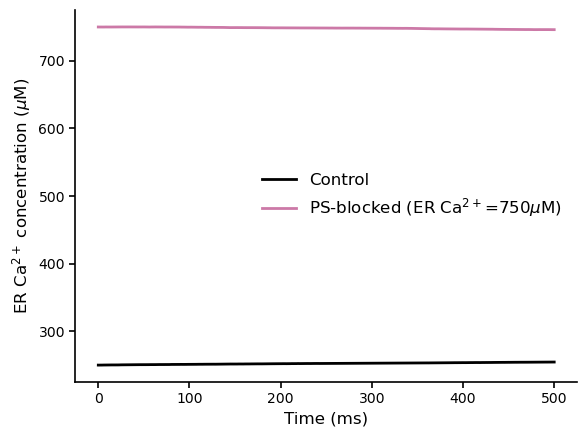

In [4]:
# ============================================================
# FIGURE
# ============================================================

fig, ax = plt.subplots(figsize=(6, 4.5))

for key in CONDITION_ORDER:
    cond = get_condition(key)
    t_ms, er_ca = traces[key]
    ax.plot(t_ms, er_ca, color=cond.color, linewidth=2, label=LEGEND_LABELS[key])

ax.set_xlabel("Time (ms)")
ax.set_ylabel(r"ER Ca$^{2+}$ concentration ($\mu$M)")
strip_spines(ax)
ax.legend(frameon=False, loc="center right")
fig.tight_layout()

save_figure(fig, SAVE_NAME)
plt.show()
